# econchile — charts tutorial

**Chilean macroeconomic data, visualized.** This notebook shows how to fetch
data with econchile and turn it into charts with matplotlib.

**How to run:** `pip install econchile matplotlib` first, then run the cells
top to bottom. A `BCCH_TOKEN` (free at
https://si3.bcentral.cl/Siete/en/Siete/API) gives live data; **without a token
the notebook falls back to the bundled offline fixture** — every chart still
renders.


In [1]:
import os
import csv
import re
from collections import OrderedDict

import matplotlib
import matplotlib.pyplot as plt

# Render charts inline in the notebook.
%matplotlib inline

import econchile
from econchile import BcchClient, Series

print(f'econchile {econchile.__version__}')
print(f'matplotlib {matplotlib.__version__}')
print(f'Token: {"yes" if os.environ.get("BCCH_TOKEN") else "no (offline fallback)"}')


econchile 0.2.0
matplotlib 3.11.1
Token: no (offline fallback)


## 1. The basic call

`client.get(series, desde, hasta)` — dates are `YYYY-MM-DD`. Returns a
typed `SeriesResult` with `.observations` (each `.date` / `.value`) and
`.source` (`"api"`, `"cache"` or `"partial"`).


In [2]:
client = BcchClient()

if os.environ.get('BCCH_TOKEN'):
    result = client.get(Series.USD, '2000-01-01', '2010-12-31')
    print(f'USD/CLP 2000-2010: {len(result.observations)} daily observations')
    print(f'Source: {result.source}')
    print('First 3 observations:')
    for obs in result.observations[:3]:
        print(f'  {obs.date}  {obs.value}')
else:
    print('No token — will use offline fixture for the charts.')
    print('Set BCCH_TOKEN and re-run for live data.')


No token — will use offline fixture for the charts.
Set BCCH_TOKEN and re-run for live data.


## 2. Chart 1 — USD/CLP line

Helpers (same as `examples/charts_demo.py`): aggregate daily observations to
month-end values. With a token this plots live API data; without one it reads
the bundled `data/macro-chile-lean.csv` fixture.


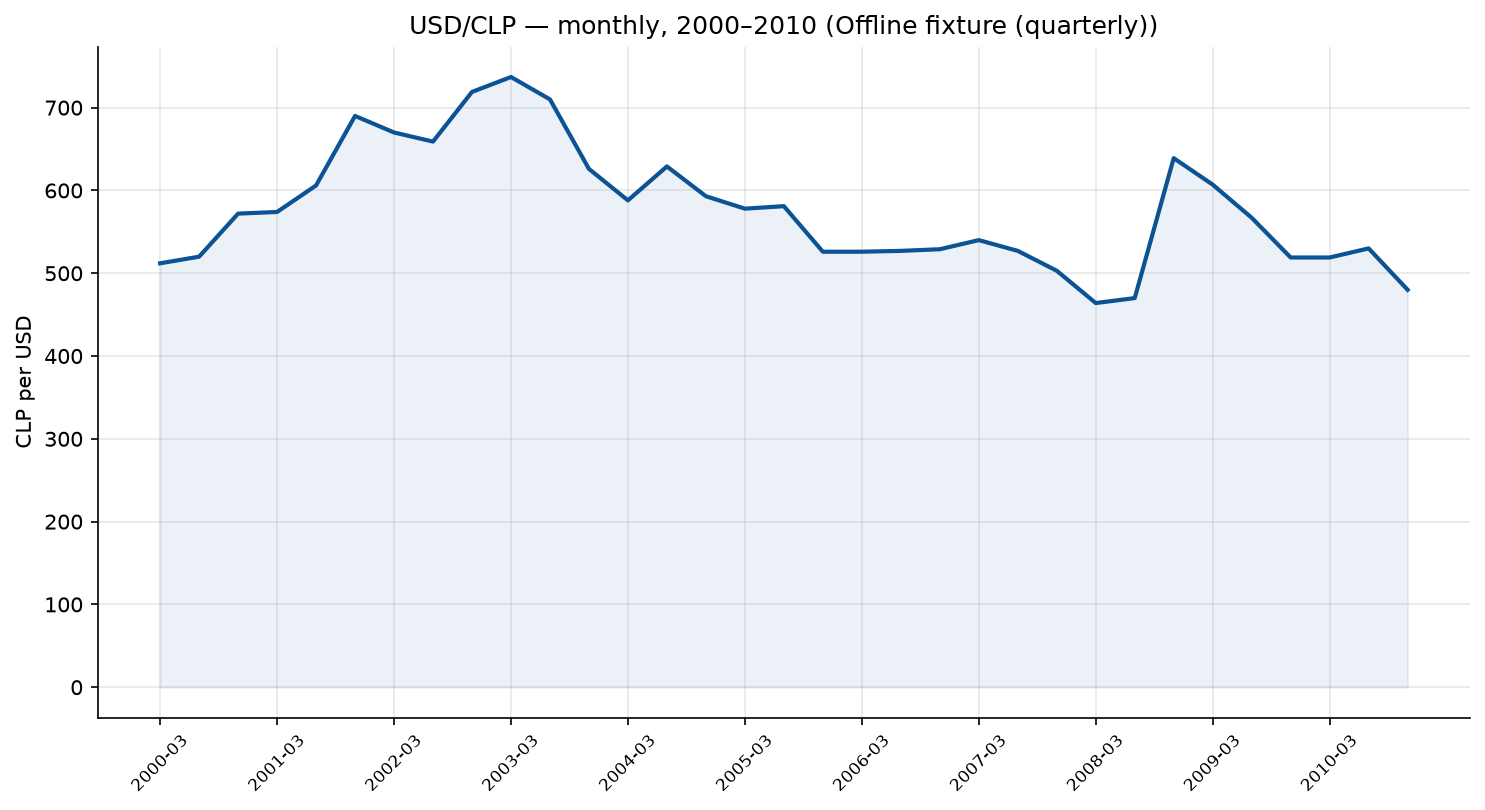

33 observations, source: Offline fixture (quarterly)


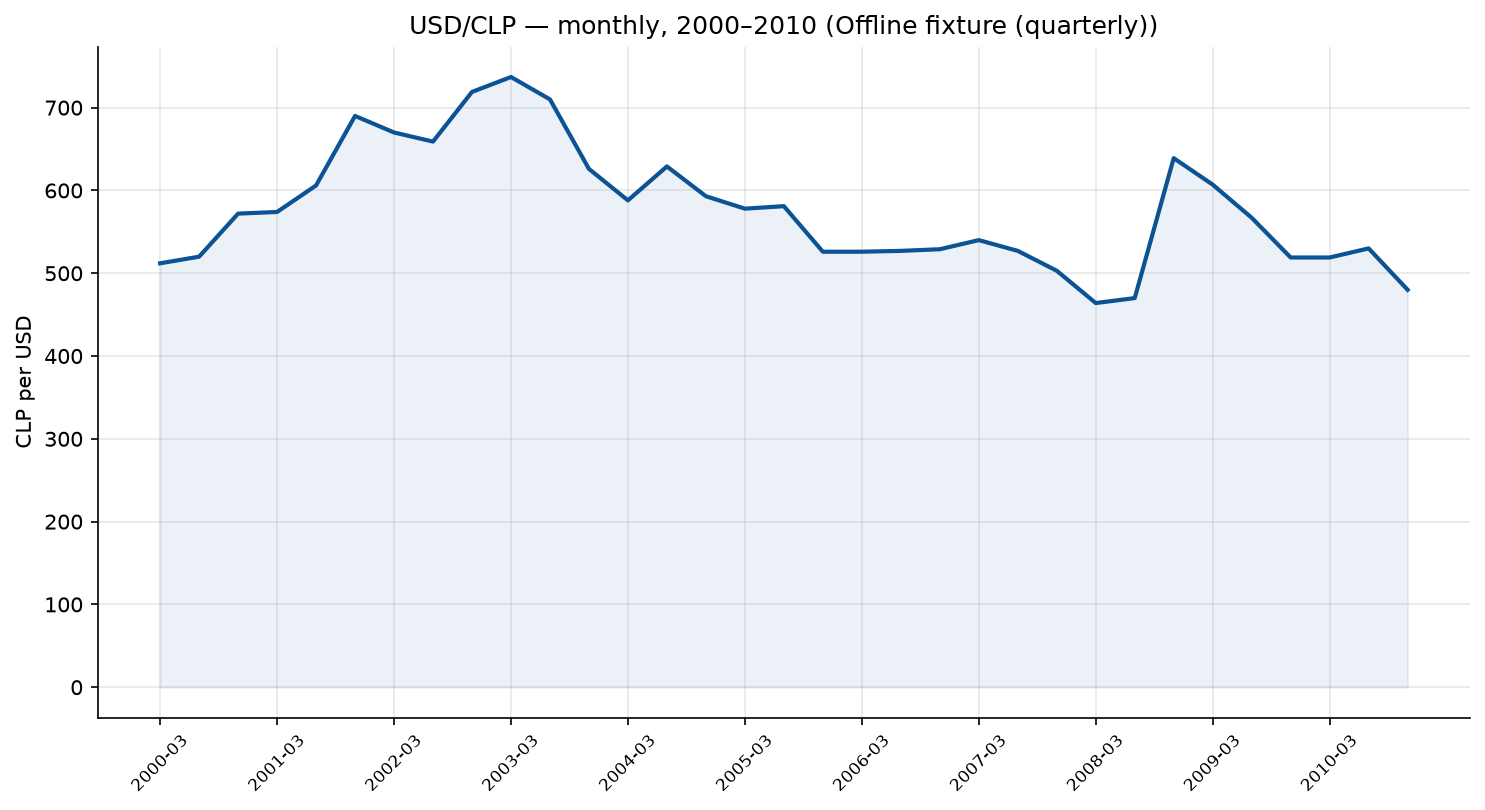

In [3]:
HERE = os.path.dirname(os.path.abspath('__file__'))
REPO_ROOT = os.path.dirname(HERE) if 'examples' in HERE else '.'
CSV_PATH = os.path.join(REPO_ROOT, 'data', 'macro-chile-lean.csv')

def _parse_period(text):
    m = re.match(r'([a-z]+)\.(\d{4})', text.strip().lower())
    if not m:
        return None
    months = {'ene': 1, 'feb': 2, 'mar': 3, 'abr': 4, 'may': 5, 'jun': 6,
              'jul': 7, 'ago': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dic': 12}
    month = months.get(m.group(1))
    if month is None:
        return None
    return (int(m.group(2)), month)

def _parse_number(text):
    if text is None:
        return None
    cleaned = text.strip().replace('\xa0', '').replace(' ', '')
    if not cleaned:
        return None
    cleaned = cleaned.replace('.', '').replace(',', '.')
    try:
        return float(cleaned)
    except ValueError:
        return None

def _load_offline_series(column='TCN'):
    out = []
    with open(CSV_PATH, encoding='utf-8-sig') as fh:
        for row in csv.DictReader(fh, delimiter=';'):
            period = _parse_period(row.get('Periodo', ''))
            value = _parse_number(row.get(column))
            if period and value is not None:
                out.append((period[0], period[1], value))
    return sorted(out)

def _monthly_from_daily(daily_obs):
    months = OrderedDict()
    for obs in daily_obs:
        if obs.value is None:
            continue
        y, m, _ = obs.date.split('-')
        months[(int(y), int(m))] = float(obs.value)
    return [(y, m, v) for (y, m), v in months.items()]

if os.environ.get('BCCH_TOKEN'):
    daily = client.get(Series.USD, '2000-01-01', '2010-12-31').observations
    series = _monthly_from_daily(daily)
    source_label = 'BCCh API (live)'
else:
    series = _load_offline_series('TCN')
    source_label = 'Offline fixture (quarterly)'

window = [(y, m, v) for (y, m, v) in series if 2000 <= y <= 2010]
x = [f'{y}-{m:02d}' for y, m, _ in window]
y = [v for _, _, v in window]

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)
ax.plot(x, y, color='#0b5394', linewidth=2)
ax.fill_between(range(len(x)), y, color='#0b5394', alpha=0.08)
ax.set_title(f'USD/CLP — monthly, 2000–2010 ({source_label})')
ax.set_ylabel('CLP per USD')
tick_step = max(1, len(x) // 10)
ax.set_xticks(range(0, len(x), tick_step))
ax.set_xticklabels([x[i] for i in range(0, len(x), tick_step)], rotation=45, fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
from IPython.display import display
display(fig)
print(f'{len(window)} observations, source: {source_label}')


## 3. Chart 2 — TPM vs IPC (dual axis)

Two series with different units on one figure: the **TPM** (monetary policy
rate, %) on the left axis and **IPC_SAE** (monthly inflation, %) on the right.


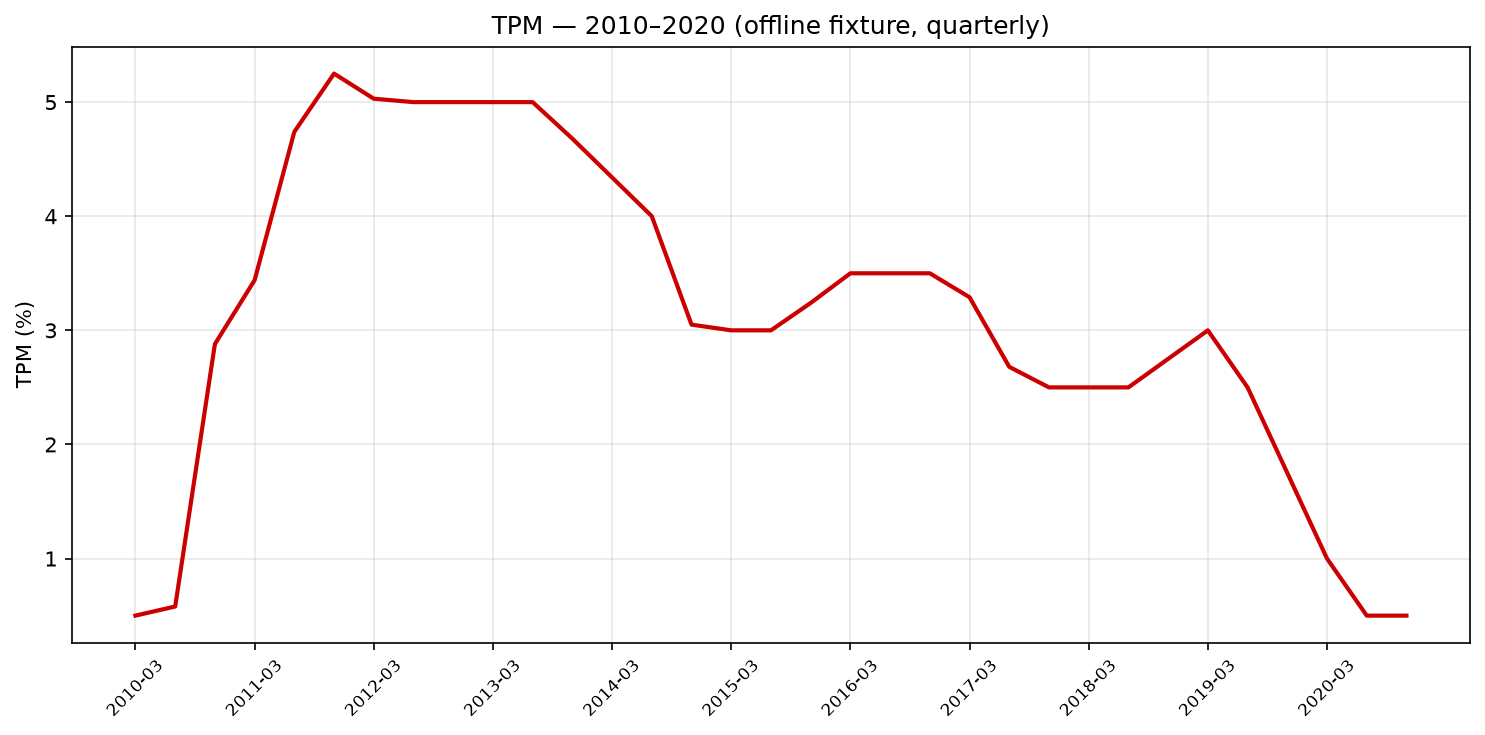

TPM offline: 33 quarterly observations


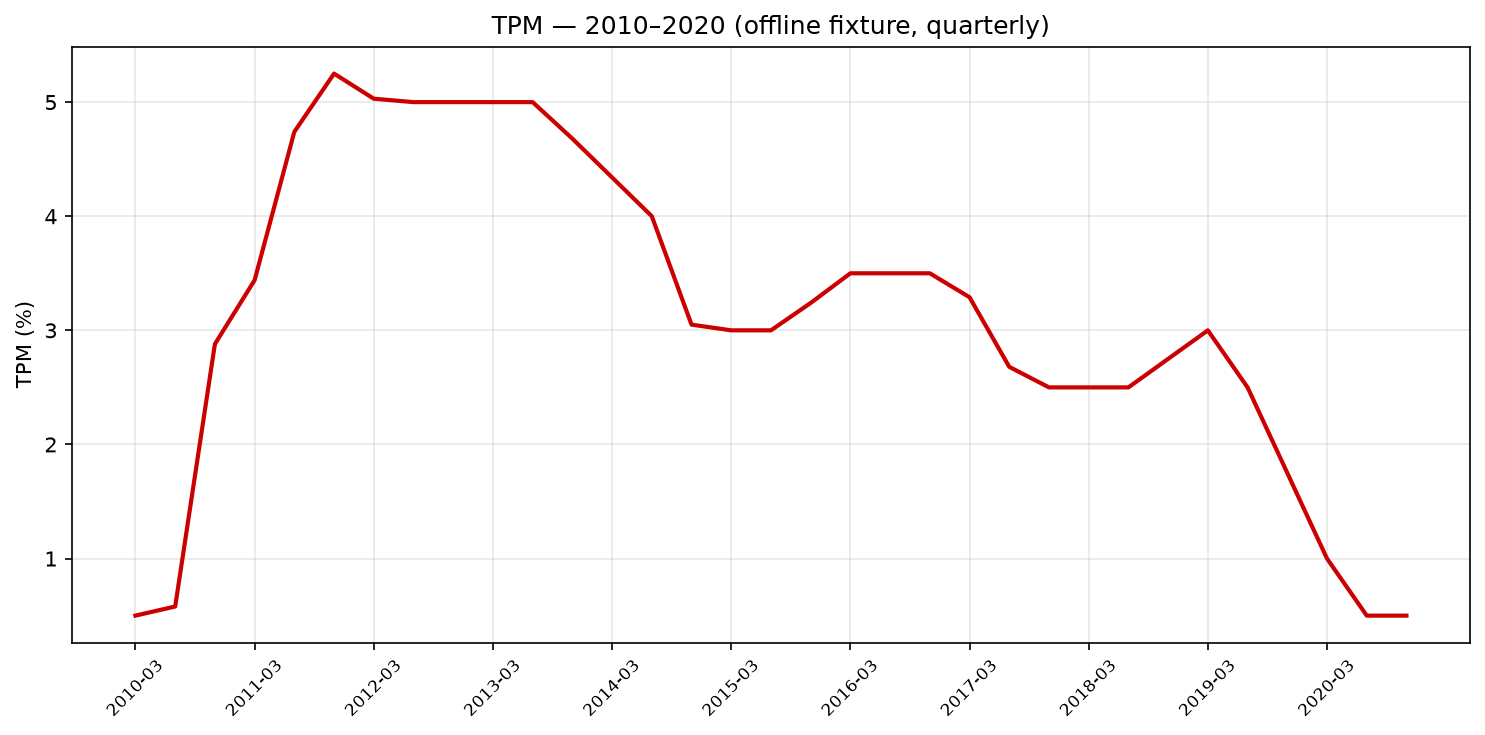

In [4]:
if os.environ.get('BCCH_TOKEN'):
    tpm = client.get(Series.TPM, '2010-01-01', '2020-12-31').observations
    ipc = client.get(Series.IPC_SAE, '2010-01-01', '2020-12-31').observations

    tpm_monthly = _monthly_from_daily(tpm)
    ipc_vals = [(int(o.date.split('-')[0]), int(o.date.split('-')[1]), o.value)
                for o in ipc if o.value is not None]

    fig, ax1 = plt.subplots(figsize=(10, 5), dpi=150)
    x1 = [f'{y}-{m:02d}' for y, m, _ in tpm_monthly]
    y1 = [v for _, _, v in tpm_monthly]
    ax1.plot(x1, y1, color='#cc0000', linewidth=2, label='TPM (left)')
    ax1.set_ylabel('TPM (%)', color='#cc0000')
    ax1.tick_params(axis='y', labelcolor='#cc0000')

    ax2 = ax1.twinx()
    x2 = [f'{y}-{m:02d}' for y, m, _ in ipc_vals]
    y2 = [v for _, _, v in ipc_vals]
    ax2.plot(x2, y2, color='#0000cc', linewidth=2, label='IPC_SAE MoM% (right)')
    ax2.set_ylabel('IPC_SAE MoM %', color='#0000cc')
    ax2.tick_params(axis='y', labelcolor='#0000cc')

    fig.suptitle('TPM vs IPC_SAE — 2010–2020 (BCCh API)')
    tick_step = max(1, len(x1) // 10)
    ax1.set_xticks(range(0, len(x1), tick_step))
    ax1.set_xticklabels([x1[i] for i in range(0, len(x1), tick_step)], rotation=45, fontsize=8)
    ax1.grid(True, alpha=0.3)
    fig.tight_layout()
    from IPython.display import display
    display(fig)
    print(f'TPM: {len(tpm_monthly)} monthly, IPC_SAE: {len(ipc_vals)} monthly')
else:
    offline = _load_offline_series('TPM')
    window = [(y, m, v) for (y, m, v) in offline if 2010 <= y <= 2020]
    x = [f'{y}-{m:02d}' for y, m, _ in window]
    y = [v for _, _, v in window]

    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
    ax.plot(x, y, color='#cc0000', linewidth=2)
    ax.set_title('TPM — 2010–2020 (offline fixture, quarterly)')
    ax.set_ylabel('TPM (%)')
    tick_step = max(1, len(x) // 10)
    ax.set_xticks(range(0, len(x), tick_step))
    ax.set_xticklabels([x[i] for i in range(0, len(x), tick_step)], rotation=45, fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    from IPython.display import display
    display(fig)
    print(f'TPM offline: {len(window)} quarterly observations')


## 4. Chart 3 — PIB bar chart

Quarterly GDP (chained volumes, base 2018). A bar chart works well for
low-frequency series.


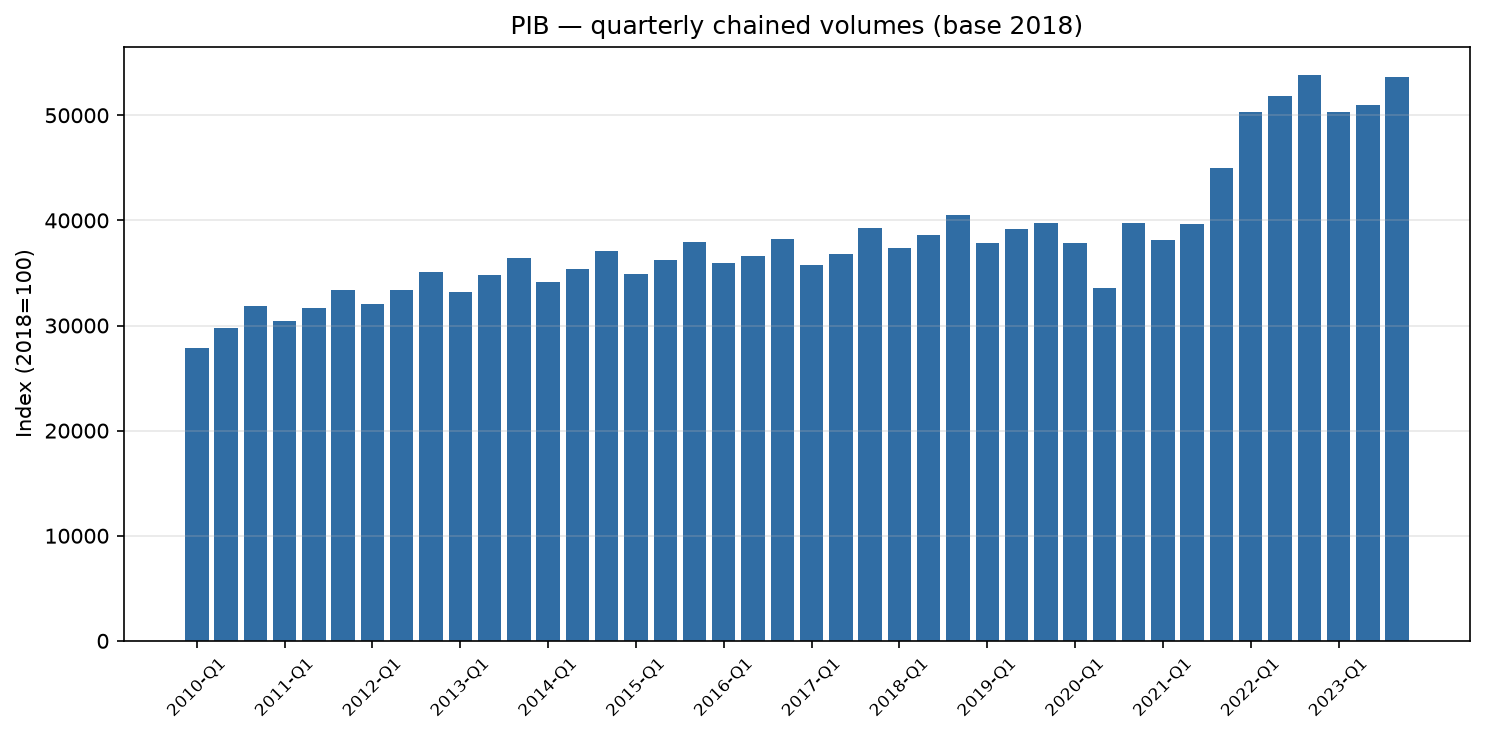

42 quarterly observations


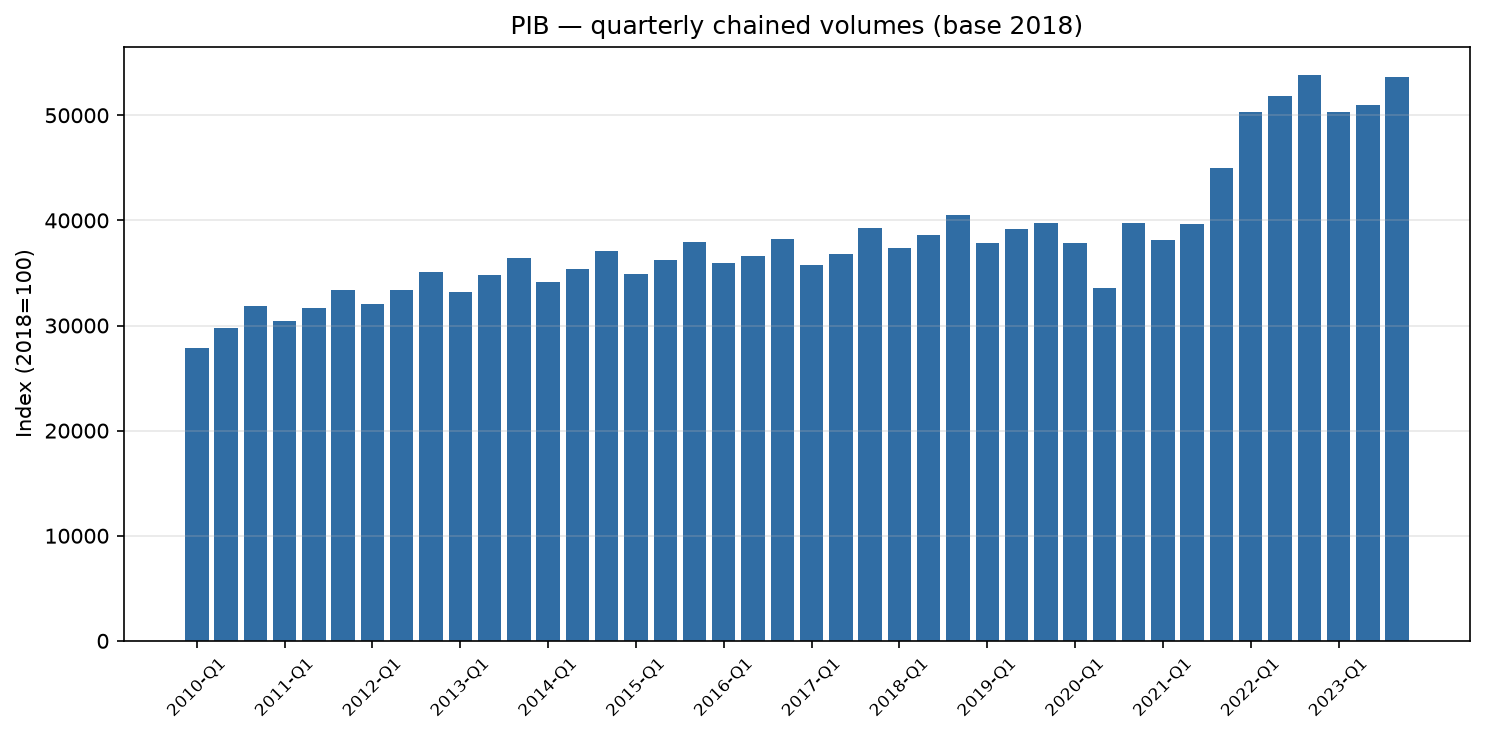

In [5]:
if os.environ.get('BCCH_TOKEN'):
    pib = client.get(Series.PIB, '2010-01-01', '2023-12-31').observations
    pib_vals = [(int(o.date.split('-')[0]), int(o.date.split('-')[1]), o.value)
                for o in pib if o.value is not None]
else:
    pib_vals = _load_offline_series('PIB')

window = [(y, m, v) for (y, m, v) in pib_vals if 2010 <= y <= 2023]
x = [f'{y}-Q{(m-1)//3+1}' for y, m, _ in window]
y = [v for _, _, v in window]

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
ax.bar(range(len(x)), y, color='#0b5394', alpha=0.85)
ax.set_title('PIB — quarterly chained volumes (base 2018)')
ax.set_ylabel('Index (2018=100)')
step = max(1, len(x) // 12)
ax.set_xticks(range(0, len(x), step))
ax.set_xticklabels([x[i] for i in range(0, len(x), step)], rotation=45, fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
from IPython.display import display
display(fig)
print(f'{len(window)} quarterly observations')


## 5. Chart 4 — IMACEC: original vs seasonally adjusted

The original series has strong **December spikes** (Chile's summer activity
surge); the seasonally-adjusted one (`IMACEC_SA`) smooths them out. Comparing
them side by side shows *why* analysts use the SA version.


In [6]:
if os.environ.get('BCCH_TOKEN'):
    imacec = client.get(Series.IMACEC, '2015-01-01', '2023-12-31').observations
    imacec_sa = client.get(Series.IMACEC_SA, '2015-01-01', '2023-12-31').observations

    orig = [(int(o.date.split('-')[0]), int(o.date.split('-')[1]), o.value)
            for o in imacec if o.value is not None]
    sa = [(int(o.date.split('-')[0]), int(o.date.split('-')[1]), o.value)
          for o in imacec_sa if o.value is not None]

    xo = [f'{y}-{m:02d}' for y, m, _ in orig]
    yo = [v for _, _, v in orig]
    xs = [f'{y}-{m:02d}' for y, m, _ in sa]
    ys = [v for _, _, v in sa]

    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
    ax.plot(xo, yo, color='#cc0000', linewidth=1.5, label='Original')
    ax.plot(xs, ys, color='#0b5394', linewidth=2, label='Seasonally adjusted')
    ax.set_title('IMACEC — original vs SA, 2015–2023 (BCCh API)')
    ax.set_ylabel('Index (2018=100)')
    tick_step = max(1, len(xo) // 12)
    ax.set_xticks(range(0, len(xo), tick_step))
    ax.set_xticklabels([xo[i] for i in range(0, len(xo), tick_step)], rotation=45, fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    from IPython.display import display
    display(fig)
    print(f'original: {len(orig)}, SA: {len(sa)} monthly observations')
else:
    print('IMACEC original vs SA needs a token (live API).')
    print('Running offline, this cell is skipped — the other charts still work.')


IMACEC original vs SA needs a token (live API).
Running offline, this cell is skipped — the other charts still work.


## 6. Offline fallback

Even **without a token**, econchile scripts can still show data: the bundled
fixture (`data/macro-chile-lean.csv`) covers the nominal exchange rate (TCN).
This is exactly what `OfflineClient` does for real scripts — API first, cache
fallback on failure.


Offline fixture: 84 observations
First: (1996, 3, 410.0)
Last: (2023, 12, 870.0)


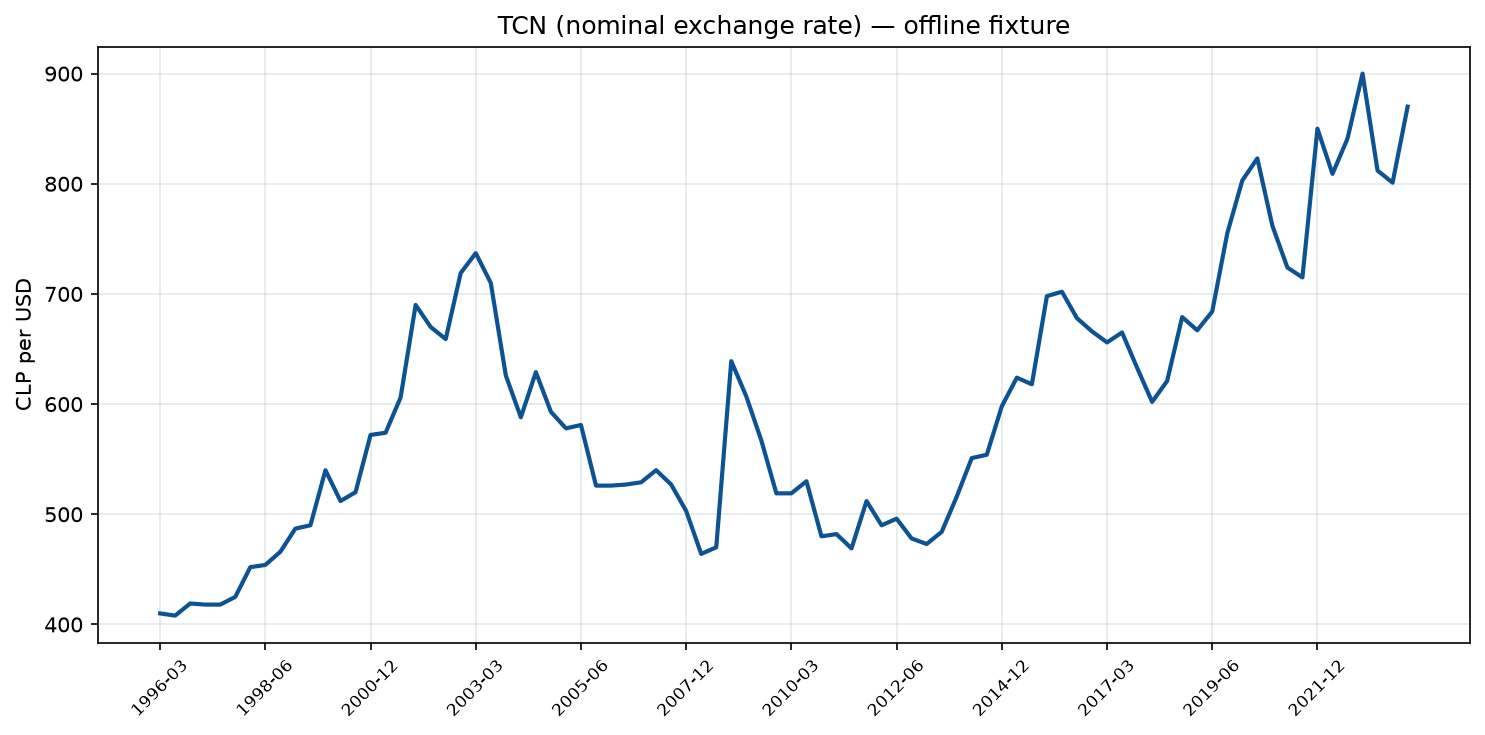

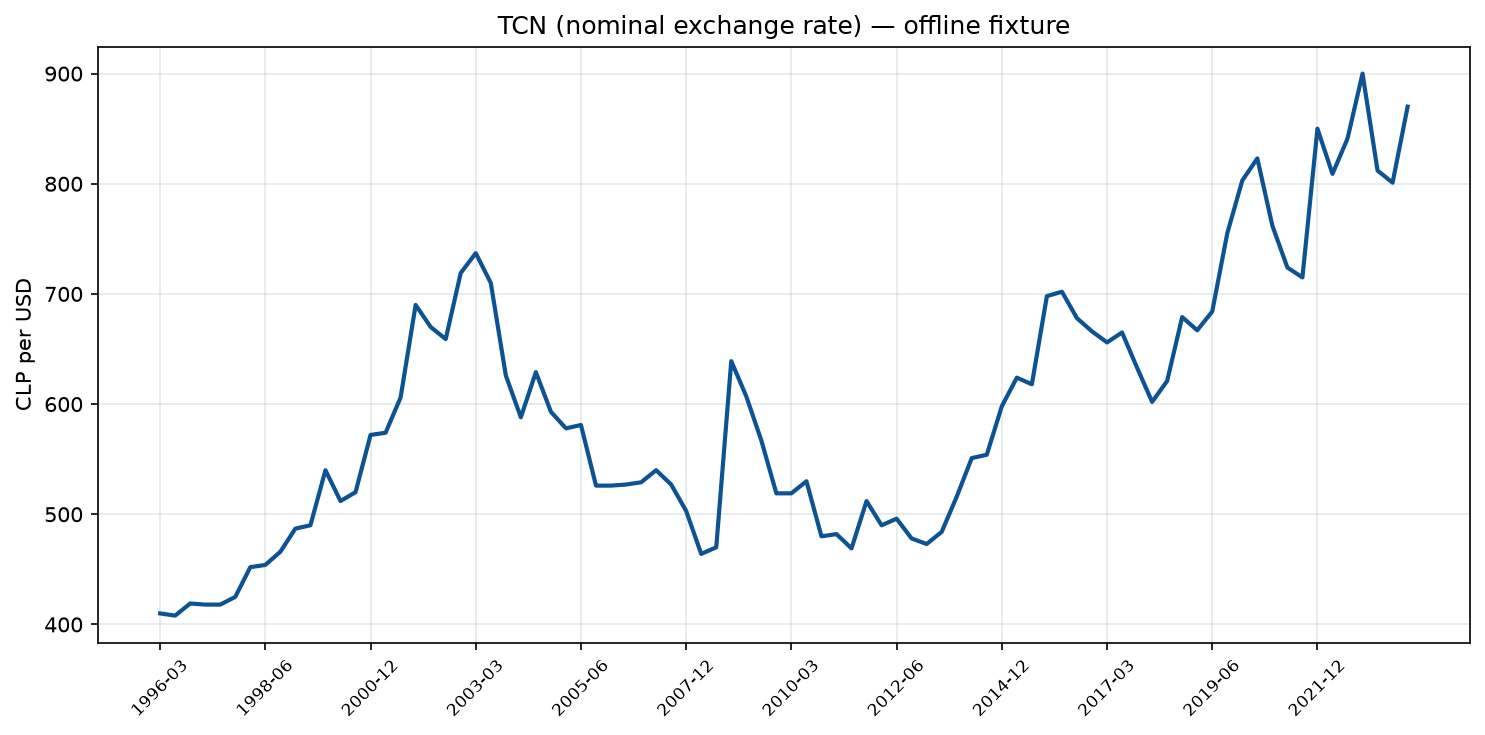

In [7]:
offline_data = _load_offline_series('TCN')
print(f'Offline fixture: {len(offline_data)} observations')
print(f'First: {offline_data[0]}')
print(f'Last: {offline_data[-1]}')

x = [f'{y}-{m:02d}' for y, m, _ in offline_data]
y = [v for _, _, v in offline_data]

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
ax.plot(x, y, color='#0b5394', linewidth=2)
ax.set_title('TCN (nominal exchange rate) — offline fixture')
ax.set_ylabel('CLP per USD')
step = max(1, len(x) // 12)
ax.set_xticks(range(0, len(x), step))
ax.set_xticklabels([x[i] for i in range(0, len(x), step)], rotation=45, fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
from IPython.display import display
display(fig)


## 7. Pitfalls & tips

- **Missing data is `None`**, never 0. The BCCh API marks gaps as `ND`;
  econchile parses them to `value=None`. Check `obs.value is None` before
  using a value.
- **`EURO` is USD per EUR** (~0.86), not CLP per EUR. Read the docstring.
- **Frequency matters**: UF/USD are daily, IPC monthly, PIB quarterly.
  Aggregating daily → month-end is up to you (see the helper above).
- **`result.source`** tells you where the data came from: `"api"`, `"cache"`
  or `"partial"`. The SQLite cache lives at `~/.econchile/cache.db` (24h TTL).
- Full catalog: any BCCh series code works via `client.get("F032.IMC...", ...)`;
  `client.search("ipc")` finds the 28 indexed series.


## What you learned

- How to fetch a series: `client.get(Series.X, desde, hasta)`
- How to inspect a `SeriesResult` (`.observations`, `.source`)
- Four chart types: line, dual-axis, bar, multi-series comparison
- How the offline fallback works without a token
- Key gotchas: `None` for missing data, EURO units, frequencies

**Next:** the API tour notebook (`examples/econchile_walkthrough.ipynb`),
the README, and the full catalog on the [v0.2.0 release](https://github.com/cristobal437/econchile/releases).
